# Final figures for "Global quantification of river confinement"
Introduction, (some) Methods and global map figures are made in QGIS and cannot be found in this node book. Other differences between the figures found in this notebook and figures in the paper stem from final adjustments made in Adobe Illustrator or by the editors.

In [30]:
# Package exports

import pandas as pd
import duckdb
import geopandas as gpd
import tqdm
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

import xarray as xr

from clustering import print_pca_loadings,\
                        data_prep_clustering, applyGMM, applyKmeans

In [2]:
dfC = pd.read_csv('/Volumes/PhD/confinement/results/dfClusterSlope.csv')

# Methods

In [68]:
%load_ext autoreload
%autoreload 2
import xml.etree.ElementTree as ET
from pathlib import Path
from dem import find_dem_bounds_FAB
from get_orthogonals import get_orthogonals
from support import adjust_new_segments, confinement_factor_single_values
from osgeo import gdal



from shapely.geometry import LineString, Point, MultiPoint, MultiLineString, Polygon
from shapely import box as Box

import numpy as np
from get_orthogonals import get_orthogonals
from dem import find_dem_FAB
from tqdm import tqdm
from support import get_ids, node_position
import glob
from osgeo import gdal
# from skimage import measure

from scipy.stats import trim_mean
import os
from extract_slope_along_raster_line import extract_slope_along_raster_line
from line_functions import getExtrapoledLine
from datetime import datetime as dt
from inflection_points import inflection_points_curve
from smoothing import SG_smoothing
from connect_geometries import merge_centerlines
import scipy as sc
from run_confinement_values import confinement_factor
from dem import get_raster_vrt
from calc_functions import confinement_values, mm_to_inch
from datetime import datetime as dt
from scipy.spatial import cKDTree


# Add a colorbar with the proper adjustments
from mpl_toolkits.axes_grid1 import make_axes_locatable

from confinement_margin import confinement_margin

from calc_functions import x_y_intercept

from confinement_margin import get_raster_side
from run_confinement_values import calc_confinement_values
from get_orthogonals import get_orthogonals
from dem import find_dem

from support import create_dir, create_custom_cmap, adjust_new_segments, update_root_path_dem_vrt
from line_functions import split_ring
from dem import find_dem_bounds_FAB

import glob
from matplotlib.patches import Patch


from support import smooth_factor, create_vrt
import warnings
warnings.filterwarnings("ignore")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
cont   = 'eu'
contID = '02'
crossFactor = 50
conFactor   = [50,10]
DEMprojection = 'EPSG:4326'

create_new = False
directory  =  '/Volumes/PhD/'

# new segment files are created in reach_definition
vector_save_file = directory + f'confinement/results/new_segments/vector/{cont}_{contID}_reach_new_segments.gpkg'
node_save_file   = directory + f'SWORD/v17/GPKG/{cont}_sword_nodes_v17.gpkg'

df     = gpd.read_file(vector_save_file)
dfNode = gpd.read_file(node_save_file)

# adjust str values to int or float
df   = adjust_new_segments(df)


In [5]:
# open confinement and smoothing factor
fname = directory + 'confinement/results/confinement_factor.csv'
if os.path.exists(fname):
    dfCF = pd.read_csv('/Volumes/PhD/confinement/results/confinement_factor.csv') # Where Do it make this again???
else:
    allResultFiles = np.sort(glob(directory + f'results/single_values/??_??_{crossFactor}.csv'))
    for i, f in enumerate(allResultFiles):
        dfTemp = pd.read_csv(f, dtype = {'include_flag':str, 'calculated':str})
        if i == 0:
            dfA = dfTemp
        else:
            dfA = pd.concat([dfA, dfTemp])

    dfCF = confinement_factor_single_values(dfA, 'bendWidths', conFactor[0], conFactor[1])
    dfCF.to_csv(directory + 'results/confinement_factor.csv')

if os.path.exists(directory + 'confinement/results/smoothingFactor.csv'):
    dfSF = pd.read_csv(directory + 'confinement/results/smoothingFactor.csv')
else:
    dfSF = smooth_factor(df, directory + 'confinement/')


In [6]:
vrt_path = directory + "confinement/results/FAB_dem_vrt.vrt"
if os.path.exists(vrt_path):
    demVRT   = gdal.Open(vrt_path)

    # use if needed
    # update_root_path_dem_vrt(directory + "confinement/results/FAB_dem_vrt.vrt",
    #                      "/home/6256481/River_Morphology/input/FAB_dem/",
    #                      "/Volumes/PhD/FABDEM/",
    #                      directory +"confinement/results/FAB_dem_vrt_updated.vrt")
else:
    create_vrt('/Volumes/PhD/FABDEM/', "/Volumes/PhD/confinement/results/")
    demVRT   = gdal.Open(vrt_path)

In [9]:
create_vrt('/Volumes/PhD/FABDEM/', "/Volumes/PhD/confinement/results/")
demVRT   = gdal.Open(vrt_path)

In [10]:

# DEMprojection = 'EPSG:4326'
# dfDemBounds = find_dem_bounds_FAB(directory+"confinement/results/", DEMprojection)
# dfDemBounds['directory'] = '/Volumes/PhD/FABDEM/'
# dfDemBounds['id'] = dfDemBounds['id'].str.split('/').str[-1]

ids = df.loc[df['include_flag'] == '0', 'combined_reach_id'].unique()
ids = [6130]


In [23]:

def run_var_extraction(id):
        dfReach      = df[df['combined_reach_id'] == id].copy()
        dfReachNodes = dfNode[dfNode['reach_id'].isin(dfReach['reach_id'].values)].copy()

        GroupedCRS = dfReach.groupby('localCRS', as_index = False).size()
        reachCRS   = GroupedCRS.loc[GroupedCRS['size'] == GroupedCRS['size'].max()
                                        ,'localCRS'].iloc[0]

        dfReach      = dfReach.to_crs(reachCRS)
        dfReachNodes = dfReachNodes.to_crs(reachCRS)
        df.loc[dfReach.index, 'combined_reach_crs'] = reachCRS           

        combinedLine, _, _ = merge_centerlines(dfReach, df, reachCRS)


        ###########################
        # Set width factor value
        ###########################
        widthVar    = 'width'
        factorWidth = dfReach['combined_reach_width'].iloc[0]
        
        if dfReachNodes[widthVar].std() > (factorWidth/2):
                factorWidth = trim_mean(dfReachNodes[widthVar], 0.05)
        if np.isnan(factorWidth):
                factorWidth = dfReachNodes[widthVar].mean()
        ###########################
        # Width Ratio
        ###########################
        widthRatio = dfReachNodes['width'] / dfReachNodes['max_width']
        df.loc[dfReach.index, 'widthRatio'] = np.nanmean(widthRatio)

        ###########################
        # Smoothing
        ###########################
        factorRow       = abs(dfSF['combined_reach_width'] - factorWidth).argsort()
        smoothingFactor = dfSF.loc[factorRow, 'smoothFactor'].iloc[0]
        
        smoothing_window = smoothingFactor*int(factorWidth) # Smoothing window based on mean node max width
                
        # Smooth centerline
        combinedLine = SG_smoothing(combinedLine, smoothing_window, factorWidth)
        if len(combinedLine.coords) < 3:
                combinedLine = combinedLine.segmentize(1) 
        
        # find node positions along combined centerline
        # add node positions after smoothing for similarity in coding
        dfReachNodes = node_position(combinedLine, dfReachNodes)


        (sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines, 
                infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc) = inflection_points_curve(combinedLine, dfReach, dfReachNodes)

        

        for i in range(1):
                po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight = get_orthogonals(combinedLine, dfReach, 
                                        apexPList, apexPOList, amplitudes ,infLines,
                                        bendLines, bendWidths,
                                        reachCRS, 'EPSG:4326',
                                        crossFactor, 
                                        -9999,demVRT,
                                        '', 400)
        return (dfReach, combinedLine, po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight,
                sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines, 
                infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc, reachCRS)


dfReach, combinedLine, po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight,\
         sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines,\
                infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc, reachCRS = run_var_extraction(6130)

In [15]:
def apexWidth(apexP, dfN):
    dfApex = gpd.GeoDataFrame({'geometry':apexP.buffer(200)}, crs = reachCRS, index = [0])



    lineNodeJoin = gpd.sjoin_nearest(dfApex, dfN)
    bendNodes    = dfN[dfN.node_id.isin(lineNodeJoin.node_id.values)]
    return bendNodes['max_width'].mean()

def plotConnection(dfReach, localCRS, df, ax, zorder = 100):
    maxOrder = dfReach['reach_order'].max()

    for s, o, c, side, style in [['up', 0, 'red', 'upstream', '--'], ['dn', maxOrder, 'red', 'red', '--']]:
        rch = dfReach.loc[dfReach['reach_order'] == o, f'rch_id_{s}'].iloc[0]
        if isinstance(rch, list):
            dfS = df.loc[df.reach_id.isin(rch)]
            dfS = dfS.to_crs(localCRS)
            if side == 'upstream':
                dfS.plot(ax =ax, color = c, zorder = zorder, linewidth = 2, linestyle = style, label = 'Connecting Reach')
            else:
                dfS.plot(ax =ax, color = c, zorder = zorder, linewidth = 2, linestyle = style)
            # l = dfS.iloc[0].geometry
            # ax.plot(*l.xy, zorder = zorder,color =  'red')

def plotExtraLine(df, rid, localCRS):
    dfReach = df[df['reach_id'] == rid].copy()
    dfReach = dfReach.to_crs(localCRS)
    line = dfReach.iloc[0]['geometry']
    return line

In [21]:
def plot(apexID,row,hf, plotProf =True, plotDEM = True, figureType = 'Regular'):
    def plot_prep(apexID):
        bendMW = bendMaxWidths[apexID]
        bendW  = bendWidths[apexID]

        heightFactor    = hf
        factorRow       = abs(dfCF['bendWidths'] - bendW).argsort()
        # 4.429160868401368
        
        conFactor = dfCF.loc[factorRow.iloc[0], 'conFactor'] * heightFactor

        maxSlope1 = (conFactor*bendW) / (0.5*bendW)

        
        (poIntercept, piIntercept,
        centerPointHeight, confinementHeight,
        slopeOut, slopeInn, EROut, ERInn) = confinement_values(po[apexID], pi[apexID], 
                                                    cdo[apexID], cdi[apexID], 
                                                                bendW, bendMW, conFactor)
        maxSlope2 = (confinementHeight-centerPointHeight) / (0.5*bendW)
        # print(maxSlope1, maxSlope2, poIntercept, piIntercept, conFactor)
        # print('Width/confheight:'.ljust(30), np.round(bendMW,5), np.round(bendMW*conFactor,5))
        # rowcm = pd.DataFrame({'localCRS':reachCRS, 'bendMaxWidths':bendMW,'bendWidths':bendW, 
        #                     'bendLines':bendLines[apexID], 'conFactor':conFactor}, index = [0])
        # r, r1, r2 = get_raster_side(combinedLine, demVRT, np.max(bendMW) * 2, reachCRS)
        # (confDistance, confDistanceLeft, 
        # confDistanceRight, bendHeight, 
        # pLeft, pRight) = confinement_margin(rowcm.iloc[0], r, r1, r2, 2, heightFactor, 10)
        demWidth        = np.max(bendW)
        rasterSize = demWidth*crossFactor if demWidth*crossFactor < 30000 else 30000*1.2
        raster = get_raster_vrt(demVRT, row, rasterSize*1.5, reachCRS, DEMprojection)
        return (poIntercept, piIntercept,
                centerPointHeight, confinementHeight,
                slopeOut, slopeInn, EROut, ERInn, raster, maxSlope2, bendW, bendMW)
    
    (poIntercept, piIntercept,
        centerPointHeight, confinementHeight,
        slopeOut, slopeInn, EROut, ERInn, raster, maxSlope, bendW, bendMW) = plot_prep(apexID)
    
    print('Confinement Ratio (in, out):'.ljust(30), np.round(ERInn,5), np.round(EROut,5))
    print('Slope (in, out):'.ljust(30), np.round(slopeInn,5), np.round(slopeOut, 5))
    print('Normalized Slope (in, out):'.ljust(30), np.round(slopeInn / maxSlope,5), np.round(slopeOut / maxSlope, 5))
    print('max slope m/m :'.ljust(30), np.round(maxSlope,5))
    # print('Slope degree (in, out):'.ljust(30), np.round(np.rad2deg(np.arctan(slopeOut * maxSlope)),5), np.round(np.rad2deg(np.arctan(slopeInn * maxSlope)), 5))

    if plotProf == True:
        #####
        # plot settings:
        axis_label_size = 15
        textSize        = 15
        axis_tick_size  = 12

        outsideColor = 'dimgray'
        innsideColor = 'dimgray'

        ############################################################
        ############################################################
        # Figure 1
        ############################################################
        ############################################################
        print('???', leftRightConf[apexID])
        if leftRightConf[apexID] == 1:
            pl, cl   = po[apexID], cdo[apexID]
            pr, cr   = pi[apexID], cdi[apexID]
            plI, prI = poIntercept, piIntercept
            leftText, rightText = 'Outer', 'Inner'
        else:
            pl, cl = pi[apexID], cdi[apexID]
            pr, cr = po[apexID], cdo[apexID]
            plI, prI = piIntercept, poIntercept
            leftText, rightText = 'Inner', 'Outer'


        minH = min(min(pl), min(pr))
        maxH = max(max(pl), max(pr))
        # if figureType == 'Methods':
        #     figWidth, figHeight = mm_to_inch(68), mm_to_inch(52)
        # elif figureType in ['Unconfined', 'Confined', 'PartialOS', 'Partial']:
        #     figWidth, figHeight = mm_to_inch(68), mm_to_inch(52)
        # else:
        figWidth, figHeight = [8,6]
        
        f, ax1 = plt.subplots(nrows = 1, ncols = 1, figsize = [figWidth, figHeight])
        ax1.plot(np.array(cl)*-1, pl, color = 'black', zorder = 0)
        ax1.plot(cr             , pr, color = 'black', zorder = 0)
        


        ##################### 
        # Slope lines ( not adjusted for Left Right)
        # if np.isnan(EROut) == False:
        #     yo = [centerPointHeight, confinementHeight]
        #     xo = [0, poIntercept]
        # else:
        #     yo = centerPointHeight + slopeOut * (cdo[apexID] - cdo[apexID][0])
        #     xo = cdo[apexID]
            
        # if np.isnan(ERInn) == False:
        #     yi = [centerPointHeight, confinementHeight]
        #     xi = [0, piIntercept*-1]
            
        # else:
        #     yi = centerPointHeight + slopeInn * (cdi[apexID] - cdi[apexID][0])
        #     xi = np.array(cdi[apexID])*-1
        # ax1.plot(xo, yo, color = 'blue', label = f'Out: {slopeOut}', zorder = 200)
        # ax1.plot(xi, yi, color = 'blue', label = f'In: {slopeInn}' , zorder = 200)
        
        #####################
        # River extend lines
        ax1.vlines(bendW/2     , minH, maxH, linestyle = '--', color = '#848484', zorder = 10)
        ax1.vlines((bendW/2)*-1, minH, maxH, linestyle = '--', color = '#848484', zorder = 10)

        # plt.axvline(bendW*5, color='g', linestyle="--")
        # plt.axvline(bendW*-5, color='g', linestyle="--")
        #####################
        # confinement height line
        if figureType in ['Unconfined', 'Methods', 'Regular']:
            ax1.hlines(confinementHeight, max(cl)*-1, max(cdo[apexID]), linestyle = '--', color = 'red', zorder = 100)
        else:
            ax1.hlines(confinementHeight, plI*-1, prI, linestyle = '--', color = 'red', zorder = 100)

        #####################
        # River centerpoint
        ax1.scatter(0, centerPointHeight, marker = '^', c = 'red', s = 150
                    , zorder = 500)
        
        #######################################
        if figureType == 'Methods':
            # paper methods figure settings
            # dist, minH, maxH = 400, 700, 800
            # xLim2 = xLim1
            # ax1.set_xticks(np.arange(-1*dist, dist+100, 100), [400,300,200,100,0,100,200,300,400])
            # loc = [0.5,0.98]
            axis_label_size = 15
            textSize        = 15
            axis_tick_size  = 12

            xLim1, xRange, minH, maxH,xstep,ystep = 250, 300, 700, 800,100,20
            xLim2 = xLim1
            ax1.set_xticks(np.arange(-1*xRange, xRange+xstep, xstep), np.append(np.arange(xRange, 0,-1*xstep), np.arange(0, xRange+xstep, xstep)))
            ax1.set_yticks(np.arange(minH+ystep, maxH, ystep), np.arange(minH+ystep, maxH, ystep))
            loc = [0.3,0.7,0.7]

        elif figureType == 'Unconfined':
            # Paper results unconfined
            xLim1, xRange, minH, maxH,xstep,ystep = 10000, 8000, -8, 12,2000,5
            xLim2 = xLim1
            ax1.set_xticks(np.arange(-1*xRange, xRange+xstep, xstep), np.append(np.arange(xRange, 0,-1*xstep), np.arange(0, xRange+xstep, xstep)))
            ax1.set_yticks(np.arange(minH+ystep, maxH, ystep), np.arange(minH+ystep, maxH, ystep))
            loc = [0.3,0.7,0.7]
        elif figureType == 'Confined':
                # Paper results confined
            xLim1, xRange, minH, maxH,xstep,ystep = 1500, 1500, 60, 290, 500, 50
            xLim2 = xLim1
            ax1.set_xticks(np.arange(-1*xRange, xRange+xstep, xstep), np.append(np.arange(xRange, 0,-1*xstep), np.arange(0, xRange+xstep, xstep)))
            ax1.set_yticks(np.arange(minH+ystep, maxH, ystep), np.arange(minH+ystep, maxH, ystep))
            loc = [0.25,0.75,0.7]
        elif figureType == 'PartialOS':
                # Paper results partial one sided
            xLim1, xRange, minH, maxH,xstep,ystep = 800, 1500, 220, 340,500,20
            xLim2 = 1800
            ax1.set_xticks(np.arange(-1*xRange, xRange+xstep, xstep), np.append(np.arange(xRange, 0,-1*xstep), np.arange(0, xRange+xstep, xstep)))
            ax1.set_yticks(np.arange(minH+ystep, maxH, ystep), np.arange(minH+ystep, maxH, ystep))
            loc = [0.1,0.65,0.6]
        elif figureType == 'Partial':
                # Paper results Partial cluster 4
            xLim1, xRange, minH, maxH,xstep,ystep = 500, 600, 540, 595,200,10
            xLim2 = xLim1
            ax1.set_xticks(np.arange(-1*xRange, xRange+xstep, xstep), np.append(np.arange(xRange, 0,-1*xstep), np.arange(0, xRange+xstep, xstep)))
            ax1.set_yticks(np.arange(minH+ystep, maxH, ystep), np.arange(minH+ystep, maxH, ystep))
            loc = [0.3, 0.7,0.7]
        else:
            xLim1, xLim2 = max(cdi[apexID])*-1, max(cdo[apexID])
            loc = [0.3,0.7,0.7]

        if figureType in ['Unconfined', 'Confined', 'PartialOS', 'Partial']:
            ax1.axis('off') 
            print(f'XRange: {xLim1 + xLim2}, YRange: {maxH-minH}, VI: {(xLim1 + xLim2) / (maxH-minH)}')
             # print(xLim1, xLim2)
            ax1.set_xlim([-1*xLim1,xLim2])
            ax1.set_ylim([minH, maxH])
        elif figureType in ['Methods']:
            ax1.axis('on') 
            ax1.set_xlim([-1*xLim1,xLim2])
            ax1.set_ylim([minH, maxH])
        else:
            ax1.axis('on') 
            ax1.set_xlim([-1000,1000])

       

        #######################################
        # text
        ax1.text(loc[0], loc[2], f"Left\n{leftText}"  , fontsize=textSize, color='black', ha="center", zorder = 300, transform=ax1.transAxes)
        ax1.text(loc[1], loc[2], f"Right\n{rightText}", fontsize=textSize, color='black', ha="center", zorder = 300, transform=ax1.transAxes)
        
        #######################################
        #labels Distance (m) Elevation (m)
        ax1.set_xlabel(''  , fontsize = axis_label_size)
        ax1.set_ylabel('' , fontsize = axis_label_size)
        # Customize tick size and color
        ax1.tick_params(axis='both', which='major', labelsize=axis_tick_size, colors='black')  # Major ticks
        
        plt.tight_layout()
        if figureType == 'Regular1':
            plt.savefig('/Volumes/PhD/confinement/results/figures/' + 
                        f'confinement_profile.svg', dpi=1000, bbox_inches = 'tight')
        else:
            plt.savefig('/Volumes/PhD/confinement/results/figures/' + 
                    f'confinement_profile_{figureType}.png', dpi=1000, bbox_inches = 'tight')
        # plt.savefig('/home/6256481/River_Morphology/' + 
                    # f'results/figures/confinement_metric.png', dpi=1000)
        plt.show()
        # fig_width_mm = f.get_size_inches()[0] * 25.4
        # print(fig_width_mm)
    if plotDEM == True:
        ############################################################
        ############################################################
        # Figure 2
        ############################################################
        ############################################################
        f, ax2 = plt.subplots(nrows = 1, ncols = 1, figsize = [8,8])
        

        ##############################
        # Plot centerline
        ax2.plot(*combinedLine.xy, zorder =10, color = 'red', linewidth = 3, label = 'Centerline')

        ##############################
        # Plot Apex points
        pointSize = 120
        for i, ap in enumerate(apexPList):
            if i != apexID:
                ax2.scatter(*ap.xy, c = 'black', marker = '^', zorder = 100, s= pointSize)
        ax2.scatter(*apexPList[apexID].xy, c = 'black', marker = '^', zorder = 1000, s = pointSize, label = 'Bend apex')


        ##############################
        # confinement lines
        ax2.plot(*lineOut[apexID].xy, color = outsideColor, label = 'Outer (Right)', linewidth = 2, linestyle = '--')
        ax2.plot(*lineInn[apexID].xy, color = innsideColor, label = 'Inner (Left)', linewidth = 2)


        ##############################
        # Plot extra line
        # for rid in [23269000441, 23269000401]:
        #     if rid in df['reach_id'].values:
        #         L = plotExtraLine(df, rid, reachCRS)
        #         ax2.plot(*L.xy, linewidth = 1, color = 'red', linestyle = '--')


        ##############################
        # axis settings
        ax2.set_aspect('equal')
        ax2.axis('off')

        ##############################
        # plot Raster
        rasterValues = raster[:,:]
        rasterValues = rasterValues.values.ravel()
        vmin = rasterValues[rasterValues != -9999].min()
        im = raster.plot(ax = ax2, vmin = vmin, vmax = raster.max(), cmap = 'terrain', zorder = 0,
                    add_colorbar=False)
        ax2.set_title('')


        ##############################
        # Colorbar
        divider = make_axes_locatable(ax2)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(im, cax=cax, shrink=0.8, aspect=10)
        cbar.ax.tick_params(labelsize=axis_tick_size)  # Adjust tick label text size
        cbar.set_label(' ', fontsize=axis_label_size, labelpad=10)
        
        ##############################
        # Legend
        times_font = FontProperties(family='Times New Roman', size=14)
        ax2.legend(fontsize = axis_label_size, prop=times_font, loc='lower right')

        ##############################
        # Get current limits
        x0, x1 = ax2.get_xlim()
        y0, y1 = ax2.get_ylim()
        # Percentage to trim
        trim_pct = 0.02  # 2%
        # Adjust limits by trimming a percentage
        x_range = x1 - x0
        y_range = y1 - y0
        ax2.set_xlim(x0 + x_range * trim_pct, x1 - x_range * trim_pct)
        ax2.set_ylim(y0 + y_range * trim_pct, y1 - y_range * trim_pct)

        ##############################
        # save image
        plt.tight_layout()
        plt.savefig('/Volumes/PhD/confinement/results/figures/' + 
                    f'confinement_metric_dem_{figureType}.png', dpi= 1000, bbox_inches = 'tight')
        plt.show()

1 van 11
Confinement Ratio (in, out):   2.86919 5.44029
Slope (in, out):               0.29985 0.15814
Normalized Slope (in, out):    0.17427 0.09191
max slope m/m :                1.72065
??? 0.0


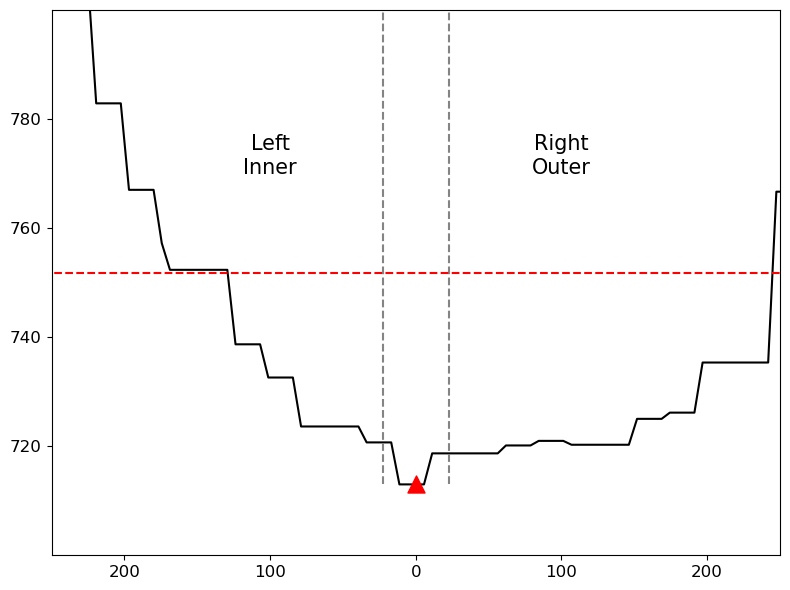

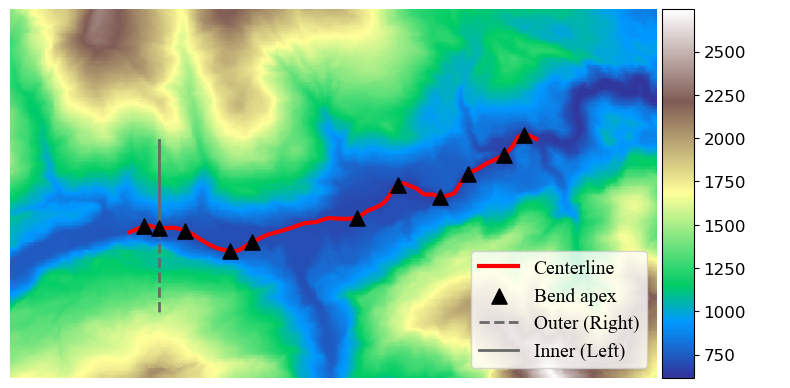

In [ ]:
figureType = 'Methods' # 6130
plot(1, dfReach,10, True, True, figureType)

# Results

In [27]:
CH = 2
# df = open_dataset_confinement_clustering(CH)
f = "/Volumes/PhD/confinement/results/single_values/global_50_02_smoothed.nc"
ds = xr.open_dataset(f)
df = ds.to_dataframe().reset_index()

In [28]:
df['slope_max'] = (df['cm_height'] - df['cp_height']) / (df['bendWidths']*0.5)
df['slope_out_normalized']   = df['slope_out']   / df['slope_max']
df['slope_inn_normalized']   = df['slope_inn']   / df['slope_max']
df['slope_left_normalized']  = df['slope_left']  / df['slope_max']
df['slope_right_normalized'] = df['slope_right'] / df['slope_max']

In [ ]:
slopeCols   = ['slope_out_normalized', 'slope_right_normalized', 'slope_left_normalized', 'slope_inn_normalized']
slopeSCols  = ['slope_out_normalized_smooth', 'slope_right_normalized_smooth', 'slope_left_normalized_smooth', 'slope_inn_normalized_smooth']
slopeECols  = ['ER_out', 'ER_left', 'ER_inn', 'ER_right']

dfCluster, pca, Xpca = data_prep_clustering(df, slopeCols+slopeSCols,True, 3, False)

## Contour plots for width vs elevation with Confinement slope and ratio as contours

Shared contour/colorbar levels:
[0.  0.1 0.2 0.3 0.4]


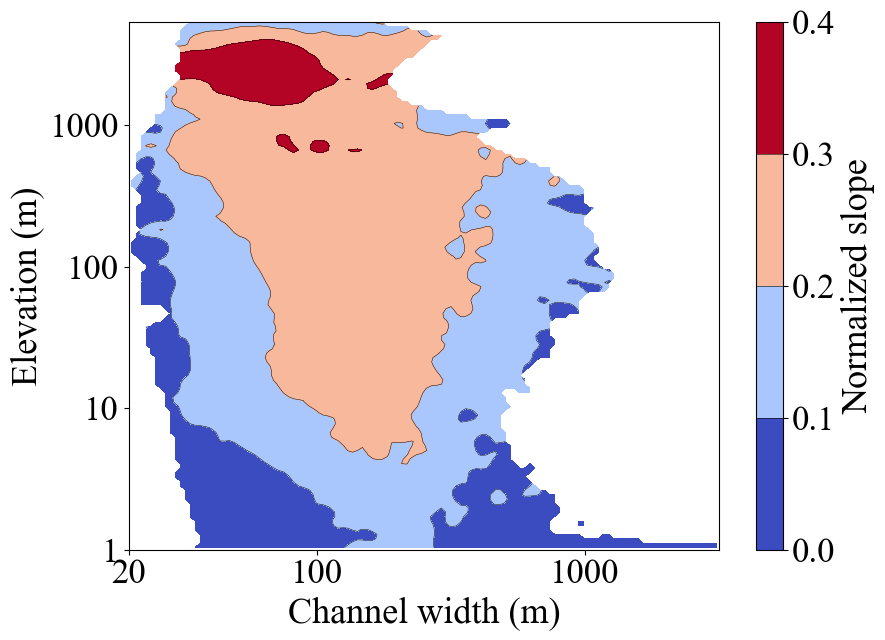


Variable: slope_diff_abs_normalized

Option 1: geometric centers
Level  0 [0.00, 0.10] | log center = (2.078, 0.748) | original center = (118.72, 4.59)
Level  1 [0.10, 0.20] | log center = (2.195, 1.562) | original center = (155.53, 35.43)
Level  2 [0.20, 0.30] | log center = (2.108, 2.285) | original center = (127.17, 191.73)
Level  3 [0.30, 0.40] | log center = (1.806, 3.350) | original center = (62.96, 2236.57)

Option 3: density-peak centers
Level  0 [0.00, 0.10] | log peak = (1.658, 0.765) | original peak = (44.45, 4.82)
Level  1 [0.10, 0.20] | log peak = (1.639, 2.451) | original peak = (42.57, 281.66)
Level  2 [0.20, 0.30] | log peak = (1.658, 2.451) | original peak = (44.45, 281.66)
Level  3 [0.30, 0.40] | log peak = (1.859, 2.888) | original peak = (71.30, 772.45)
Shared contour/colorbar levels:
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7]


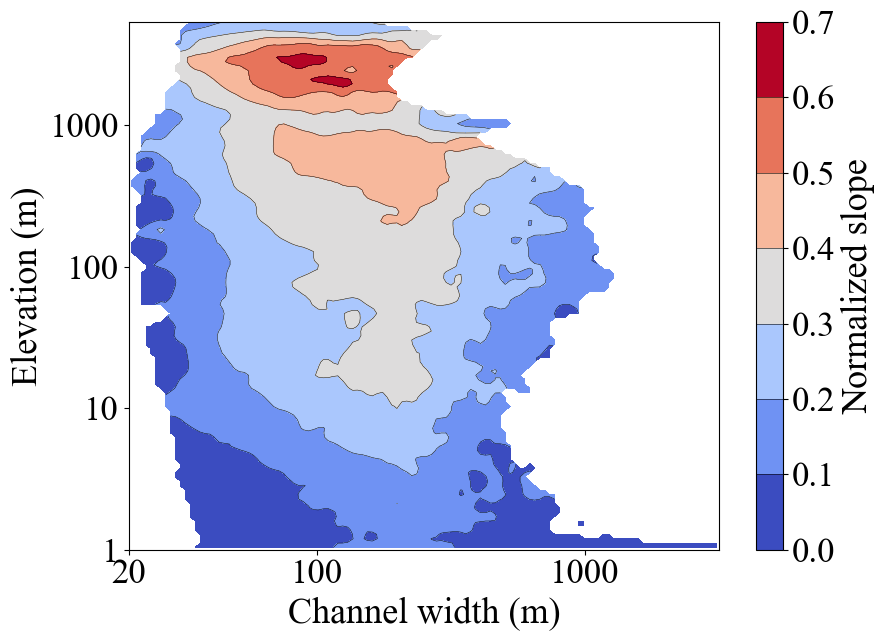

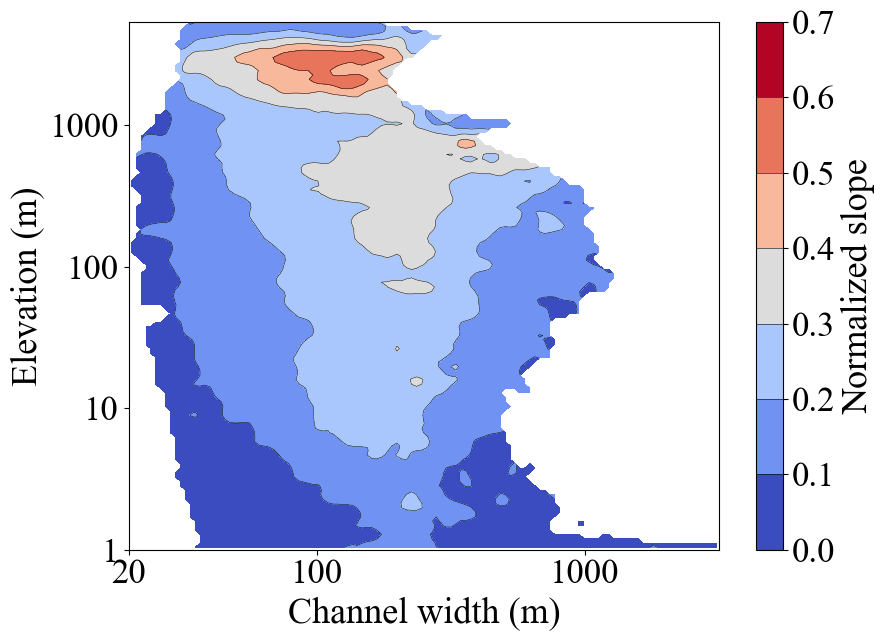


Variable: slope_out_normalized

Option 1: geometric centers
Level  0 [0.00, 0.10] | log center = (2.008, 0.637) | original center = (100.85, 3.34)
Level  1 [0.10, 0.20] | log center = (2.187, 1.259) | original center = (152.98, 17.17)
Level  2 [0.20, 0.30] | log center = (2.124, 1.908) | original center = (131.93, 79.94)
Level  3 [0.30, 0.40] | log center = (2.143, 2.347) | original center = (137.84, 221.44)
Level  4 [0.40, 0.50] | log center = (2.111, 2.944) | original center = (127.98, 877.26)
Level  5 [0.50, 0.60] | log center = (2.016, 3.399) | original center = (102.68, 2506.85)
Level  6 [0.60, 0.70] | log center = (1.988, 3.406) | original center = (96.28, 2545.24)

Option 3: density-peak centers
Level  0 [0.00, 0.10] | log peak = (1.658, 0.734) | original peak = (44.45, 4.42)
Level  1 [0.10, 0.20] | log peak = (1.658, 2.108) | original peak = (44.45, 127.17)
Level  2 [0.20, 0.30] | log peak = (1.658, 2.451) | original peak = (44.45, 281.66)
Level  3 [0.30, 0.40] | log peak = (1

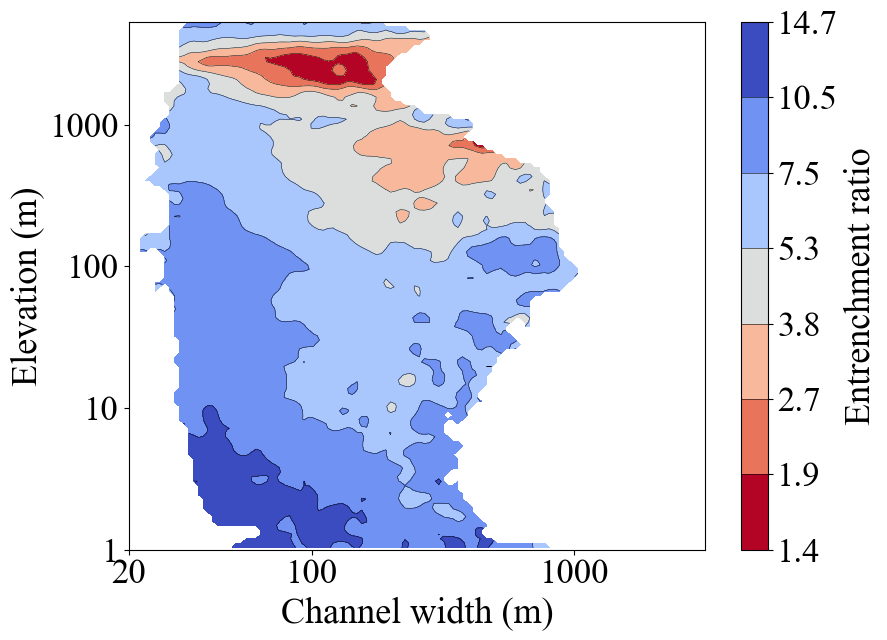


Variable: ER_diff_abs

Option 1: geometric centers
Level  0 [1.38, 1.94] | log center = (2.069, 3.387) | original center = (116.21, 2437.52)
Level  1 [1.94, 2.72] | log center = (2.023, 3.378) | original center = (104.52, 2387.98)
Level  2 [2.72, 3.81] | log center = (2.247, 3.008) | original center = (175.81, 1016.64)
Level  3 [3.81, 5.35] | log center = (2.239, 2.691) | original center = (172.35, 490.27)
Level  4 [5.35, 7.50] | log center = (2.138, 1.988) | original center = (136.49, 96.28)
Level  5 [7.50, 10.51] | log center = (1.997, 1.240) | original center = (98.25, 16.38)
Level  6 [10.51, 14.74] | log center = (1.838, 0.364) | original center = (67.94, 1.31)

Option 3: density-peak centers
Level  0 [1.38, 1.94] | log peak = (1.823, 3.475) | original peak = (65.45, 2987.42)
Level  1 [1.94, 2.72] | log peak = (1.658, 3.475) | original peak = (44.45, 2987.42)
Level  2 [2.72, 3.81] | log peak = (1.676, 3.538) | original peak = (46.41, 3448.70)
Level  3 [3.81, 5.35] | log peak = (1.

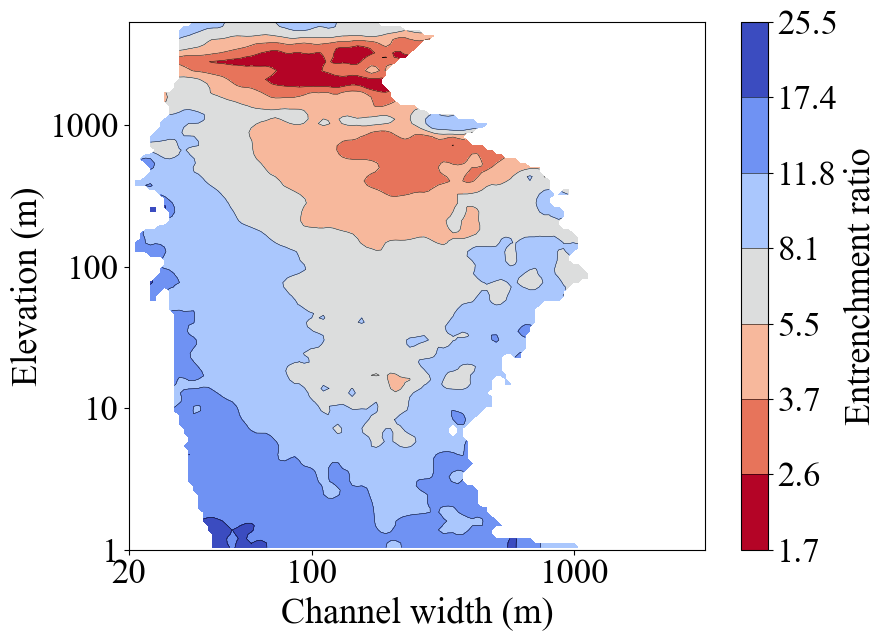

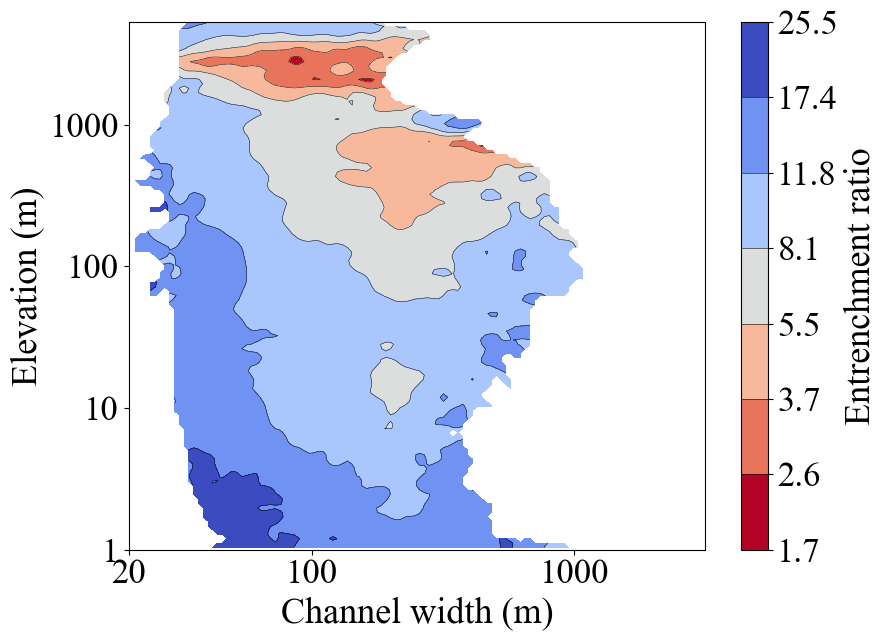


Variable: ER_out

Option 1: geometric centers
Level  0 [1.74, 2.56] | log center = (2.013, 3.401) | original center = (102.12, 2515.74)
Level  1 [2.56, 3.75] | log center = (2.181, 3.078) | original center = (150.63, 1196.97)
Level  2 [3.75, 5.50] | log center = (2.149, 2.764) | original center = (140.08, 579.97)
Level  3 [5.50, 8.07] | log center = (2.190, 2.132) | original center = (153.76, 134.53)
Level  4 [8.07, 11.83] | log center = (2.073, 1.537) | original center = (117.24, 33.42)
Level  5 [11.83, 17.36] | log center = (1.957, 0.563) | original center = (89.65, 2.66)
Level  6 [17.36, 25.46] | log center = (1.761, 0.308) | original center = (56.68, 1.03)

Option 3: density-peak centers
Level  0 [1.74, 2.56] | log peak = (1.658, 3.451) | original peak = (44.45, 2820.69)
Level  1 [2.56, 3.75] | log peak = (2.116, 2.795) | original peak = (129.57, 622.38)
Level  2 [3.75, 5.50] | log peak = (1.786, 2.795) | original peak = (60.07, 622.38)
Level  3 [5.50, 8.07] | log peak = (1.658, 2

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy.ndimage import gaussian_filter

def create_contour_figures(dfP, vars_to_plot, cbar_label, level_step, saveN, use_log_levels, n_levels
                           ,base_cmap, titles, save_dir):
    
    save_names = [f"{save_dir}contour_WE{saveN}_{S}.png" for S in titles]
    
    [save_dir + f'contour_WE{saveN}_diff.png']
    
    nx, ny = 120, 120
    sigma = 1.2
    min_support = 5

    xmin_log = 1.3   # ~ 20 m
    xmax_log = 3.5   # ~ 3161 m


    dpi_save = 300

    # -------------------------
    # FONT SETTINGS
    # -------------------------
    font_family = 'Times New Roman'
    title_size = 18
    label_size = 26
    tick_size = 25
    cbar_label_size = 26
    cbar_tick_size = 25

    plt.rcParams['font.family'] = font_family
    plt.rcParams['axes.titlesize'] = title_size
    plt.rcParams['axes.labelsize'] = label_size
    plt.rcParams['xtick.labelsize'] = tick_size
    plt.rcParams['ytick.labelsize'] = tick_size

    # =========================================================
    # FIRST PASS: COMPUTE BOTH SMOOTHED FIELDS
    # =========================================================
    plot_data = {}

    for c in vars_to_plot:
        x = dfP["bendWidths"].to_numpy()
        y = dfP["bendHeight"].to_numpy()
        z = dfP[c].to_numpy()

        mask = (
            np.isfinite(x) &
            np.isfinite(y) &
            np.isfinite(z) &
            (x >= 0) &
            (y >= 0)
        )

        x = x[mask]
        y = y[mask]
        z = z[mask]

        x_plot = np.log10(x + 1)
        y_plot = np.log10(y + 1)

        mask_xy = (x_plot >= xmin_log) & (x_plot <= xmax_log)
        x_plot = x_plot[mask_xy]
        y_plot = y_plot[mask_xy]
        z = z[mask_xy]

        xedges = np.linspace(xmin_log, xmax_log, nx + 1)
        yedges = np.linspace(np.nanmin(y_plot), np.nanmax(y_plot), ny + 1)

        sum_z, _, _ = np.histogram2d(x_plot, y_plot, bins=[xedges, yedges], weights=z)
        count, _, _ = np.histogram2d(x_plot, y_plot, bins=[xedges, yedges])

        sum_z_s = gaussian_filter(sum_z, sigma=sigma)
        count_s = gaussian_filter(count.astype(float), sigma=sigma)

        Zsmooth = np.divide(
            sum_z_s,
            count_s,
            out=np.full_like(sum_z_s, np.nan),
            where=count_s > 0
        )

        Zsmooth[count_s < min_support] = np.nan

        xc = 0.5 * (xedges[:-1] + xedges[1:])
        yc = 0.5 * (yedges[:-1] + yedges[1:])
        X, Y = np.meshgrid(xc, yc, indexing="ij")

        plot_data[c] = {
            "X": X,
            "Y": Y,
            "Zsmooth": Zsmooth,
            "count_s": count_s
        }

    # =========================================================
    # SHARED OBSERVED LEVELS ACROSS BOTH FIELDS
    # =========================================================
    all_z = np.concatenate([
        plot_data[c]["Zsmooth"][np.isfinite(plot_data[c]["Zsmooth"])]
        for c in vars_to_plot
    ])


    shared_min = np.nanmin(all_z)
    shared_max = np.nanmax(all_z)

    if use_log_levels:
        # geomspace requires strictly positive values
        shared_min = max(shared_min, 1e-3)
        levels = np.geomspace(shared_min, shared_max, n_levels)
    else:
        shared_min = np.floor(shared_min / level_step) * level_step
        shared_max = np.ceil(shared_max / level_step) * level_step

        if shared_min == shared_max:
            shared_min -= level_step
            shared_max += level_step

        levels = np.arange(shared_min, shared_max + level_step / 2, level_step)

    print("Shared contour/colorbar levels:")
    print(levels)

    # =========================================================
    # DISCRETE COLORMAP
    # =========================================================
    colors = base_cmap(np.linspace(0, 1, len(levels) - 1))
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    # =========================================================
    # PLOTTING: TWO SEPARATE FIGURES
    # =========================================================
    all_centers = {}

    for i, c in enumerate(vars_to_plot):
        X = plot_data[c]["X"]
        Y = plot_data[c]["Y"]
        Zsmooth = plot_data[c]["Zsmooth"]
        count_s = plot_data[c]["count_s"]

        fig, ax = plt.subplots(figsize=(9, 6.5))

        # filled contours
        cf = ax.contourf(
            X, Y, Zsmooth,
            levels=levels,
            cmap=cmap,
            norm=norm,
            extend='neither'
        )

        # contour lines
        ax.contour(
            X, Y, Zsmooth,
            levels=levels,
            colors='k',
            linewidths=0.35
        )

        # -------------------------
        # compute centers
        # -------------------------
        option1_centers = []
        option3_centers = []

        for j in range(len(levels) - 1):
            low = levels[j]
            high = levels[j + 1]

            if j == len(levels) - 2:
                band_mask = (
                    np.isfinite(Zsmooth) &
                    (Zsmooth >= low) &
                    (Zsmooth <= high)
                )
            else:
                band_mask = (
                    np.isfinite(Zsmooth) &
                    (Zsmooth >= low) &
                    (Zsmooth < high)
                )

            if not np.any(band_mask):
                continue

            # Option 1: geometric center
            x_center_log = np.nanmean(X[band_mask])
            y_center_log = np.nanmean(Y[band_mask])

            x_center_orig = 10**x_center_log - 1
            y_center_orig = 10**y_center_log - 1

            option1_centers.append({
                "level_index": j,
                "level_low": low,
                "level_high": high,
                "x_log": x_center_log,
                "y_log": y_center_log,
                "x_orig": x_center_orig,
                "y_orig": y_center_orig
            })

            # ax.scatter(
            #     x_center_log, y_center_log,
            #     s=45, c='black', marker='o',
            #     edgecolor='white', linewidth=0.6, zorder=10
            # )

            # Option 3: highest density cell inside the level band
            density_in_band = np.where(band_mask, count_s, np.nan)

            if not np.all(np.isnan(density_in_band)):
                peak_idx = np.nanargmax(density_in_band)
                ix, iy = np.unravel_index(peak_idx, density_in_band.shape)

                x_peak_log = X[ix, iy]
                y_peak_log = Y[ix, iy]

                x_peak_orig = 10**x_peak_log - 1
                y_peak_orig = 10**y_peak_log - 1

                option3_centers.append({
                    "level_index": j,
                    "level_low": low,
                    "level_high": high,
                    "x_log": x_peak_log,
                    "y_log": y_peak_log,
                    "x_orig": x_peak_orig,
                    "y_orig": y_peak_orig
                })

                # ax.scatter(
                #     x_peak_log, y_peak_log,
                #     s=55, c='yellow', marker='X',
                #     edgecolor='black', linewidth=0.6, zorder=11
                # )

        all_centers[c] = {
            "option1_geometric_center": option1_centers,
            "option3_density_peak": option3_centers
        }

        # -------------------------
        # colorbar
        # -------------------------
        cbar = fig.colorbar(
            cf,
            ax=ax,
            boundaries=levels,
            ticks=levels,
            spacing='uniform',
            drawedges=True
        )
        cbar.set_ticklabels([f"{lv:.1f}" for lv in levels])
        cbar.set_label(cbar_label, fontsize=cbar_label_size, fontname=font_family)
        cbar.ax.tick_params(labelsize=cbar_tick_size)

        # force Times New Roman on colorbar tick labels
        for ticklab in cbar.ax.get_yticklabels():
            ticklab.set_fontname(font_family)

        # -------------------------
        # axis formatting
        # -------------------------
        ax.set_xlim(xmin_log, xmax_log)

        xticks_log = np.array([1.3, 2, 3])
        xtick_labels = ['20', '100', '1000']
        ax.set_xticks(xticks_log)
        ax.set_xticklabels(xtick_labels, fontname=font_family)

        yticks_log = np.array([0, 1, 2, 3])
        ytick_labels = ['1', '10', '100', '1000']
        ax.set_yticks(yticks_log)
        ax.set_yticklabels(ytick_labels, fontname=font_family)

        ax.set_xlabel("Channel width (m)", fontsize=label_size, fontname=font_family)
        ax.set_ylabel("Elevation (m)", fontsize=label_size, fontname=font_family)
        # ax.set_title(titles[i], fontsize=title_size, fontname=font_family)

        ax.tick_params(axis='both', which='major', labelsize=tick_size)

        plt.tight_layout()
        plt.savefig(save_names[i], dpi=dpi_save, bbox_inches='tight')
        plt.show()

    # =========================================================
    # PRINT CENTERS
    # =========================================================
    for var_name, result in all_centers.items():
        print(f"\n{'='*80}")
        print(f"Variable: {var_name}")
        print(f"{'='*80}")

        print("\nOption 1: geometric centers")
        for item in result["option1_geometric_center"]:
            print(
                f"Level {item['level_index']:2d} "
                f"[{item['level_low']:.2f}, {item['level_high']:.2f}] | "
                f"log center = ({item['x_log']:.3f}, {item['y_log']:.3f}) | "
                f"original center = ({item['x_orig']:.2f}, {item['y_orig']:.2f})"
            )

        print("\nOption 3: density-peak centers")
        for item in result["option3_density_peak"]:
            print(
                f"Level {item['level_index']:2d} "
                f"[{item['level_low']:.2f}, {item['level_high']:.2f}] | "
                f"log peak = ({item['x_log']:.3f}, {item['y_log']:.3f}) | "
                f"original peak = ({item['x_orig']:.2f}, {item['y_orig']:.2f})"
            )


# =========================================================
# SETTINGS
# =========================================================
dfP = dfCluster.copy()
save_dir = '/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/'


dfP['slope_diff_abs_normalized'] = abs(dfP['slope_out_normalized'] - dfP['slope_inn_normalized'])

create_contour_figures(dfP, ['slope_diff_abs_normalized'], "Normalized slope", 0.1, 'S', False, 8
                           ,plt.cm.coolwarm,  ['diff'], save_dir)

create_contour_figures(dfP, ['slope_out_normalized', 'slope_inn_normalized'], "Normalized slope", 0.1, 'S', False, 8
                           ,plt.cm.coolwarm,  ['out', 'inn'], save_dir)


# ER difference
dfP['ER_diff_abs'] = abs(dfP['ER_out'] - dfP['ER_inn'])
create_contour_figures(dfP, ['ER_diff_abs'], "Entrenchment ratio", 0.1, 'E', True, 8
                           ,plt.cm.coolwarm_r,  ['diff'], save_dir)

create_contour_figures(dfP, ['ER_out', 'ER_inn'], "Entrenchment ratio", 0.1, 'E', True, 8
                           ,plt.cm.coolwarm_r,  ['out', 'inn'], save_dir)



## Distribution

In [37]:
import seaborn as sns

In [39]:
dfCluster['ER_out_log'] = np.log10(dfCluster['ER_out'])
dfCluster['ER_inn_log'] = np.log10(dfCluster['ER_inn'])

dfCluster['slope_out_normalized_log'] = np.log10(dfCluster['slope_out_normalized'])
dfCluster['slope_inn_normalized_log'] = np.log10(dfCluster['slope_inn_normalized'])

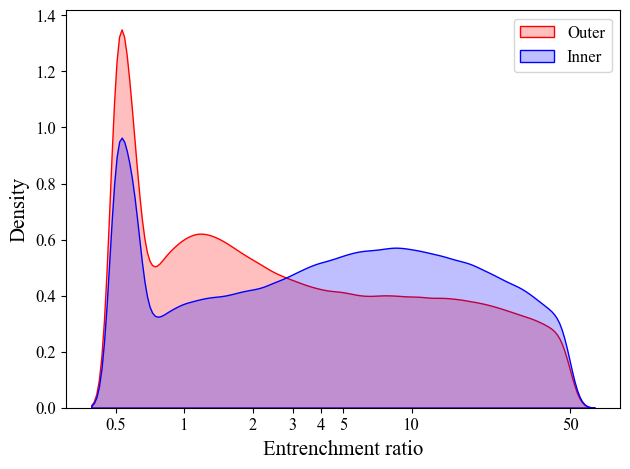

In [45]:
labelsize = 15
tickSize = 12
f,ax = plt.subplots()
sns.kdeplot(data = dfCluster,x = 'ER_out_log', fill=True, ax = ax, color = 'red' , label = 'Outer')
sns.kdeplot(data = dfCluster,x = 'ER_inn_log', fill=True, ax = ax, color = 'blue', label = 'Inner')
ax.set_xlabel('Entrenchment ratio', fontsize = labelsize)
ax.set_ylabel('Density', fontsize = labelsize)
ax.tick_params(axis = 'both', which = 'major', labelsize = tickSize)

plt.legend(title_fontsize = 12, fontsize = 12)
ax.set_xticks([-0.301 ,0.0 ,0.301 ,0.477 ,0.602 ,0.699 ,1.0, 1.699], [0.5,1,2,3,4,5,10, 50])
# plt.xlim([-3.5, 0])
plt.tight_layout()
# plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/norm_slope_inOut_02_KDE.png', dpi = 1000)
plt.show()

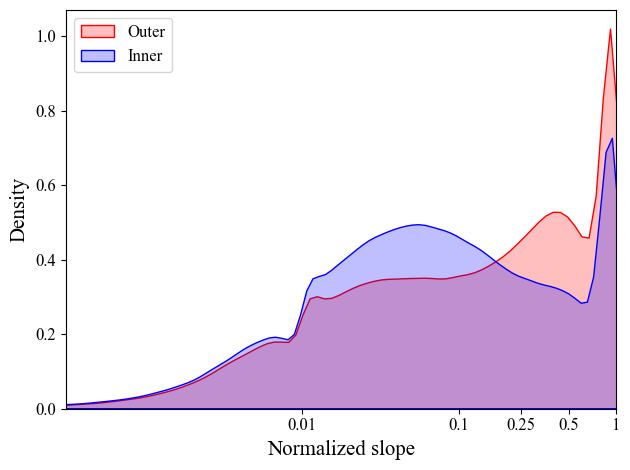

In [42]:
labelsize = 15
tickSize = 12
f,ax = plt.subplots()
sns.kdeplot(data = dfCluster,x = 'slope_out_normalized_log', fill=True, ax = ax, color = 'red' , label = 'Outer')
sns.kdeplot(data = dfCluster,x = 'slope_inn_normalized_log', fill=True, ax = ax, color = 'blue', label = 'Inner')
ax.set_xlabel('Normalized slope', fontsize = labelsize)
ax.set_ylabel('Density', fontsize = labelsize)
ax.tick_params(axis = 'both', which = 'major', labelsize = tickSize)

plt.legend(title_fontsize = 12, fontsize = 12)
ax.set_xticks([0.0 ,-2, -1,-0.602, -0.301], [1,0.01, 0.1, 0.25, 0.5])
plt.xlim([-3.5, 0])
plt.tight_layout()
# plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/norm_slope_inOut_02_KDE.png', dpi = 1000)
plt.show()

In [ ]:
folder = "/Volumes/PhD/SWOT/RiverSP_D_parq/node/"

quality_flag = 1
dark_freq = 0.5
xtrk_dist = [10000, 60000]
df = duckdb.query(f"""
    SELECT any_value(reach_id), node_id, any_value(p_dist_out), MEDIAN(wse_sm)
    FROM read_parquet('{folder}/*.parquet')
    WHERE wse_sm_u <= {quality_flag} AND dark_frac <= {dark_freq} AND
                ABS(xtrk_dist) BETWEEN {xtrk_dist[0]} AND {xtrk_dist[1]}
    GROUP BY node_id
""").to_df()

## Confinement profiles

In [56]:
from scipy.stats import gaussian_kde
import pickle

In [ ]:
clusters = 7
dfCluster = applyGMM(dfCluster, ['PCA1', 'PCA2', 'PCA3'], clusters, 'kmeans', 100, 'tied', 5)


In [ ]:
def apply_kde(df, cluster, maxCluster, comb, res=200, det_tol=1e-12):
    d = df.loc[df[f'GMM_{maxCluster}_hard'] == cluster, comb].copy()
    d = d.apply(pd.to_numeric, errors='coerce')
    d = d[np.isfinite(d).all(axis=1)]

    if len(d) < 3:
        print(f'Not enough finite points for {comb}: cluster {cluster}')
        return None

    x = d[comb[0]].to_numpy()
    y = d[comb[1]].to_numpy()

    cov = np.cov(np.vstack([x, y]))
    det = np.linalg.det(cov)

    if (not np.isfinite(cov).all()) or (det <= det_tol):
        print(f'Singular / near-singular covariance for {comb}: cluster {cluster}')
        return None

    kde = gaussian_kde(np.vstack([x, y]))

    xmin, xmax = x.min() - 1, x.max() + 1
    ymin, ymax = y.min() - 1, y.max() + 1
    X, Y = np.meshgrid(np.linspace(xmin, xmax, res),
                       np.linspace(ymin, ymax, res))
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    return X, Y, Z




In [86]:
combs = [['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized']]
combNames = ['KDE_slopeOut_vs_slopeLeft', 'KDE_slopeInn_vs_slopeLeft']
clusters = 7
kde_list = []
for comb in combs:
    print(combs)
    k = []
    for c in tqdm(range(clusters)):
    # for c in [1]:
        k.append(apply_kde(dfCluster, c, clusters, comb, 100))
    kde_list.append(k)

    
    # with open('/Volumes/PhD/confinement/KDE_slopeOut_vs_slopeLeft.pkl', 'wb') as f:
    #     pickle.dump(k, f)

[['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized']]


 14%|█▍        | 1/7 [00:28<02:51, 28.53s/it]

Singular / near-singular covariance for ['slope_out_normalized', 'slope_left_normalized']: cluster 1


 43%|████▎     | 3/7 [00:31<00:34,  8.60s/it]

Singular / near-singular covariance for ['slope_out_normalized', 'slope_left_normalized']: cluster 3


...

[['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized']]


 57%|█████▋    | 4/7 [00:36<00:19,  6.46s/it]

Singular / near-singular covariance for ['slope_inn_normalized', 'slope_left_normalized']: cluster 4


100%|██████████| 7/7 [00:41<00:00,  5.86s/it]

Singular / near-singular covariance for ['slope_inn_normalized', 'slope_left_normalized']: cluster 6


['slope_out_normalized', 'slope_left_normalized']
['slope_inn_normalized', 'slope_left_normalized']


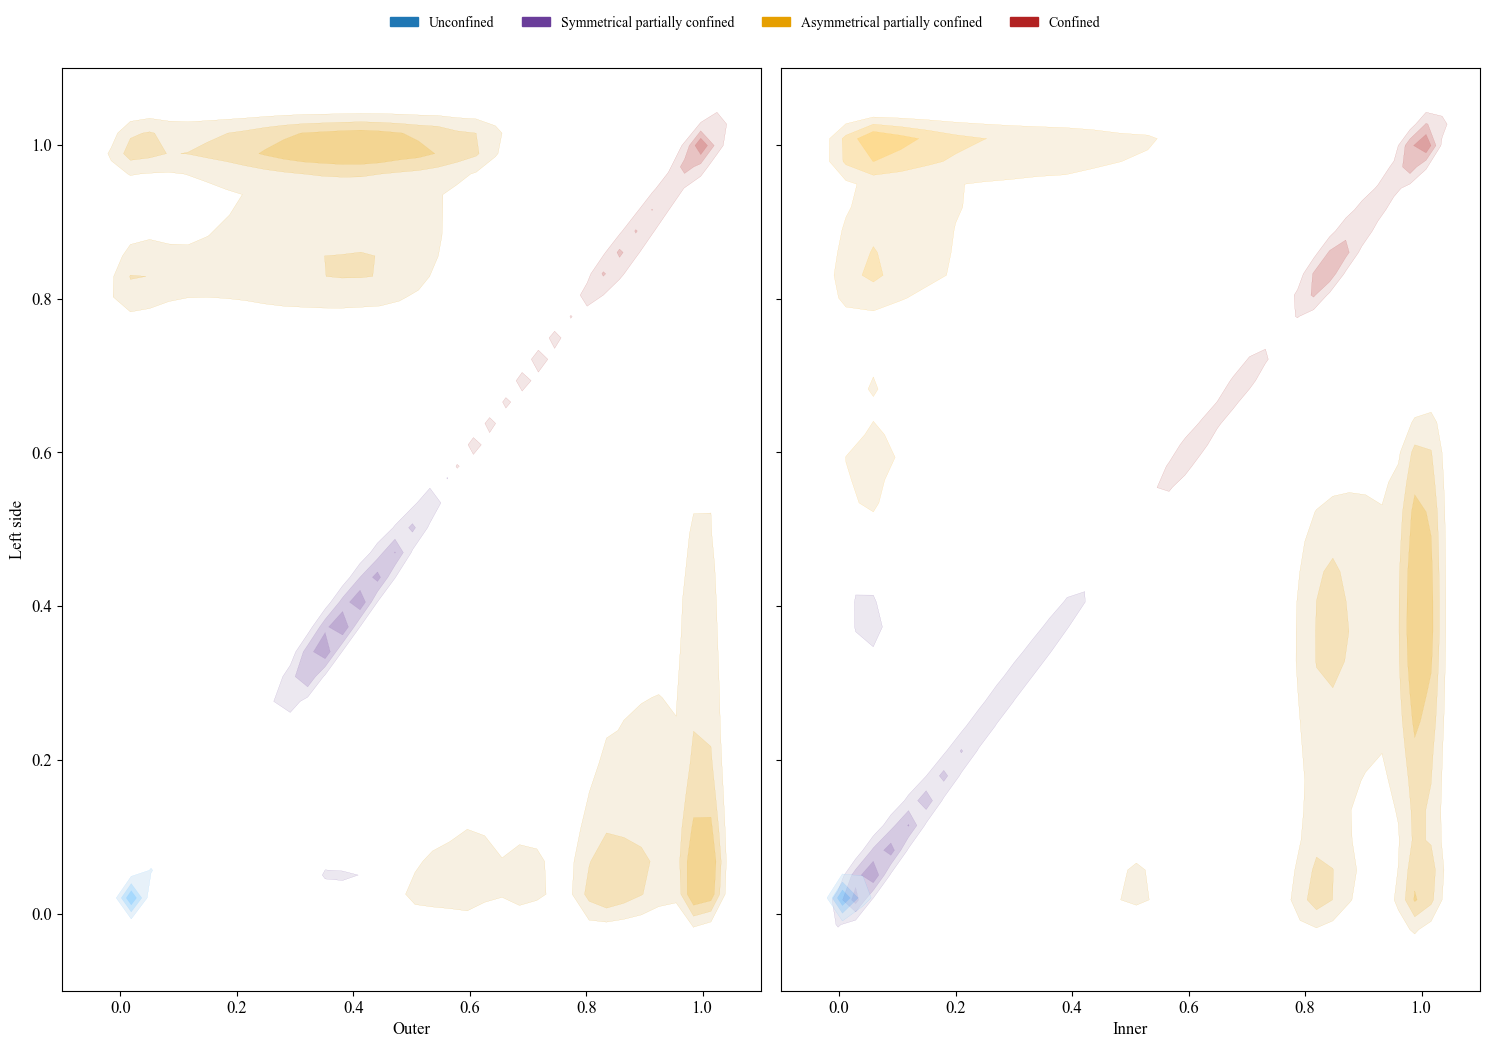

In [ ]:
colors = ["#2fa8ff", "#e69f00", "#b22222", "#ffae00", '#e69f00','#6a3d9a', '#e69f00']
xlab = ['Outer', 'Inner', 'Outer', 'Inner']
f,ax = plt.subplots(ncols = 2, nrows = 1, figsize = [15,10], squeeze = False, sharey = True)
ax = ax.flatten()
for i, comb in enumerate(combs[0:2]):
    print(comb)
    for c in range(clusters):
        if kde_list[i][c] is not None:
            X, Y, Z = kde_list[i][c]

            ZRel = Z/Z.max()
            Z    = np.where(ZRel < 0.001, np.nan, ZRel)

            # Define contour levels ABOVE min_density
            Z_min = np.nanmin(Z)
            Z_max = np.nanmax(Z)
            n_levels = 4
            levels = np.linspace(Z_min, Z_max, n_levels)  # lowest contour starts above min_density
            levels = np.array([0.001, 0.25, 0.5, 0.75, 1.0])
            if all(levels == 0):
                continue
            # print(c, levels)
            # Filled contours (shades of one color)
            cmap = sns.light_palette(colors[c], as_cmap=True)
            if c == 0:
                zz = 1000
            else:
                zz = 1
            cf  = ax[i].contourf(X, Y, Z, levels=levels[1:], cmap=cmap, alpha = 0.5, antialiased = True, zorder = zz)

            
            ax[i].set_xlim([-0.1,1.1])
            ax[i].set_ylim([-0.1,1.1])
            ax[i].set_xlabel(xlab[i], fontsize = 12)
            ax[i].tick_params(axis='both', which='major', labelsize=tickSize)

            cs = ax[i].contour(X, Y, Z, levels=levels[0:], colors=colors[c], linewidths=0.07)

# Create legend handles manually (to ensure one instance of each label)

legendColors = colors
legendLabels = list(np.arange(len(colors)))
handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

legendColors = colors = ['#1f77b4','#6a3d9a', "#e69f00", "#b22222"]
legendLabels = ['Unconfined','Symmetrical partially confined', 'Asymmetrical partially confined' , 'Confined']
handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

# Add shared legend at the top center
lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=8,
    frameon=False,
    title_fontsize = 12
)
ax[0].set_ylabel('Left side', fontsize = 12)


plt.tight_layout()
# plt.savefig(f'/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/'+f'KDE_confinement_clustering_{clusters}_4.svg', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 2000)
plt.show()

# Appendix

In [ ]:
clusters = 7
dfCluster = applyGMM(dfCluster, ['PCA1', 'PCA2', 'PCA3'], clusters, 'kmeans', 100, 'tied', 5)

cols_of_interest = [col for col in dfCluster.columns if col.startswith(f"GMM_{clusters}_") and col.endswith("_soft")]
for thres in [0.9,0.95,0.99]:
    dfCluster.loc[dfCluster[cols_of_interest].max(axis=1) >= thres, f'GMM_{clusters}_{int(thres*100)}'] = dfCluster[f'GMM_{clusters}_hard']


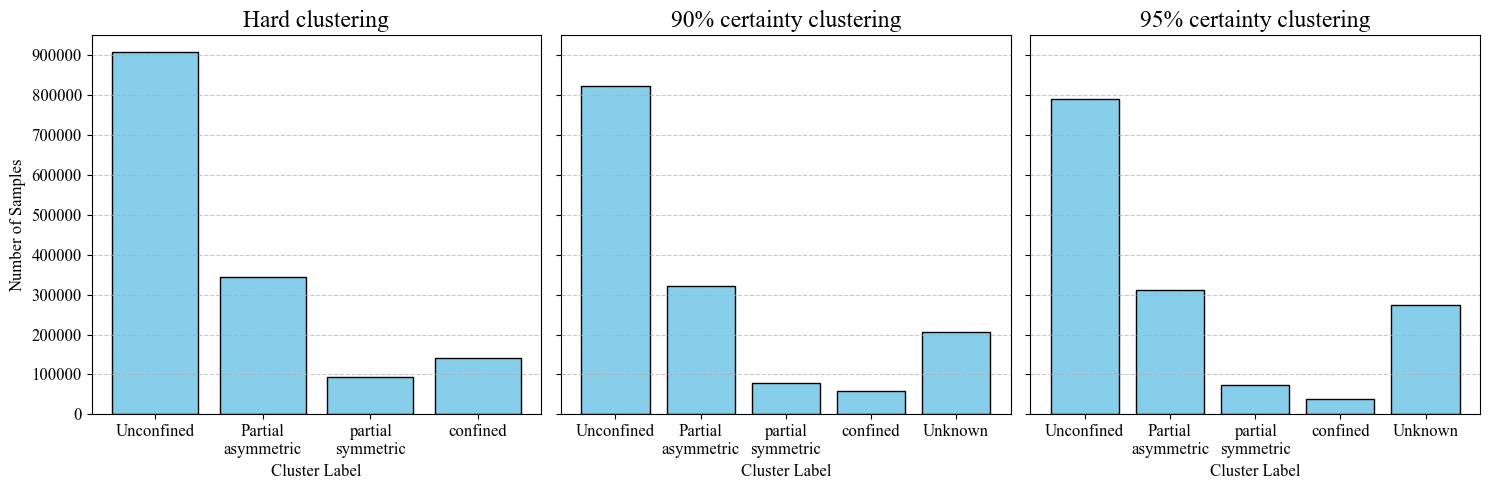

In [53]:
i = 0
levels = ['hard', '90', '95']
f,ax =plt.subplots(ncols = len(levels), nrows = 1, squeeze = False, figsize = [15,5], sharey =True)

titles = ['Hard clustering', '90% certainty clustering', '95% certainty clustering', '99% certainty clustering']
for i in range(len(levels)):
    labels = dfCluster[f'GMM_{clusters}_{levels[i]}']
    labels[labels == 4] = 1
    labels[labels == 6] = 1
    labels[labels == 3] = 1
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    # Optional: sort clusters by label
    sorted_indices = np.argsort(unique_labels)
    unique_labels = unique_labels[sorted_indices]
    counts = counts[sorted_indices]

    if levels[i] == 'hard':
        unique_labels = ['Unconfined', 'Partial\nasymmetric', 'partial\nsymmetric', 'confined']
    else:
        unique_labels = ['Unconfined', 'Partial\nasymmetric', 'partial\nsymmetric', 'confined', 'Unknown']
    ax[0,i].bar([str(lbl) for lbl in unique_labels], counts, color='skyblue', edgecolor='black')
    ax[0,i].set_yticks(np.arange(0, 1.2e6, 1e5))
    ax[0,i].set_xlabel("Cluster Label", fontsize = 12)
    ax[0,i].tick_params(axis='x', labelsize=12)
    ax[0,i].tick_params(axis='y', labelsize=12)
    
    ax[0,i].set_title(titles[i], fontsize = 17)
    ax[0,i].grid(axis='y', linestyle='--', alpha=0.7)
    ax[0,i].set_ylim(0,950000)
ax[0,0].set_ylabel("Number of Samples", fontsize = 12)
plt.tight_layout()
# plt.savefig('/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/GMM_7_hist.png')
plt.show()

## Cluster distribution

In [88]:
def apply_kde(df, cluster, maxCluster, comb, res=200, det_tol=1e-12):
    d = df.loc[df[f'GMM_{maxCluster}_hard'] == cluster, comb].copy()
    d = d.apply(pd.to_numeric, errors='coerce')
    d = d[np.isfinite(d).all(axis=1)]

    if len(d) < 3:
        print(f'Not enough finite points for {comb}: cluster {cluster}')
        return None

    x = d[comb[0]].to_numpy()
    y = d[comb[1]].to_numpy()

    cov = np.cov(np.vstack([x, y]))
    det = np.linalg.det(cov)

    if (not np.isfinite(cov).all()) or (det <= det_tol):
        print(f'Singular / near-singular covariance for {comb}: cluster {cluster}')
        return None

    kde = gaussian_kde(np.vstack([x, y]))

    xmin, xmax = x.min() - 1, x.max() + 1
    ymin, ymax = y.min() - 1, y.max() + 1
    X, Y = np.meshgrid(np.linspace(xmin, xmax, res),
                       np.linspace(ymin, ymax, res))
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    return X, Y, Z

combs = [['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized'],
         ['slope_out_normalized', 'slope_right_normalized'], ['slope_right_normalized', 'slope_right_normalized']]
combNames = ['KDE_slopeOut_vs_slopeLeft', 'KDE_slopeInn_vs_slopeLeft']
clusters = 7
kde_list = []
for comb in combs:
    print(combs)
    k = []
    for c in tqdm(range(clusters)):
    # for c in [1]:
        k.append(apply_kde(dfCluster, c, clusters, comb, 100))
    kde_list.append(k)

    
    # with open('/Volumes/PhD/confinement/KDE_slopeOut_vs_slopeLeft.pkl', 'wb') as f:
    #     pickle.dump(k, f)


[['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized'], ['slope_out_normalized', 'slope_right_normalized'], ['slope_right_normalized', 'slope_right_normalized']]


 14%|█▍        | 1/7 [00:32<03:15, 32.53s/it]

Singular / near-singular covariance for ['slope_out_normalized', 'slope_left_normalized']: cluster 1


 43%|████▎     | 3/7 [00:36<00:39,  9.80s/it]

Singular / near-singular covariance for ['slope_out_normalized', 'slope_left_normalized']: cluster 3


...

Singular / near-singular covariance for ['slope_out_normalized', 'slope_right_normalized']: cluster 4


100%|██████████| 7/7 [00:36<00:00,  5.28s/it]


Singular / near-singular covariance for ['slope_out_normalized', 'slope_right_normalized']: cluster 6
[['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized'], ['slope_out_normalized', 'slope_right_normalized'], ['slope_right_normalized', 'slope_right_normalized']]


  0%|          | 0/7 [00:00<?, ?it/s]

: 

In [ ]:
colors = ['#1f77b4', "#e69f00", "#b22222", "#ffae00", '#e69f00','#6a3d9a', '#e69f00']
colors = ['#1F4E79', '#2A9D8F',  '#8B2C2C','#E69F00', "#7B6ED6",'#4D4D4D', '#E6D3A3']
# xlab = ['Outer', 'Inner', 'Outer', 'Inner']
f,ax = plt.subplots(ncols = 2, nrows = 2, figsize = [15,10], squeeze = False, sharey = True, sharex = True)
ax = ax.flatten()
for i, comb in enumerate(combs):
    print(comb)
    for c in range(clusters):
        if kde_list[i][c] is not None:
            X, Y, Z = kde_list[i][c]

            ZRel = Z/Z.max()
            Z    = np.where(ZRel < 0.001, np.nan, ZRel)

            # Define contour levels ABOVE min_density
            Z_min = np.nanmin(Z)
            Z_max = np.nanmax(Z)
            n_levels = 4
            levels = np.linspace(Z_min, Z_max, n_levels)  # lowest contour starts above min_density
            levels = np.array([0.001, 0.25, 0.5, 0.75, 1.0])
            if all(levels == 0):
                continue
            # print(c, levels)
            # Filled contours (shades of one color)
            cmap = sns.light_palette(colors[c], as_cmap=True)
            if c == 0:
                zz = 1000
            else:
                zz = 10
            cf  = ax[i].contourf(X, Y, Z, levels=levels[1:], cmap=cmap, alpha = 0.5, antialiased = True, zorder = zz)
            # This is the fix for the white lines between contour levels
            # cf.set_edgecolor("face")
            # Contour lines (single color, skip lowest)
            
            ax[i].set_xlim([-0.1,1.1])
            ax[i].set_ylim([-0.1,1.1])
            # ax[i].set_xlabel(xlab[i], fontsize = labelSize)
            # ax[i].set_ylabel(axisLabels[comb[1]],fontsize = labelSize)
            ax[i].tick_params(axis='both', which='major', labelsize=tickSize)
            # Scatter original points
            # ax.scatter(x, y, s=10, facecolor="white", edgecolor="k", alpha=0.6)

            # Axes and grid
            # ax.set_facecolor("white")
            # ax.grid(True, linestyle="--", alpha=0.5)

            # Colorbar
            # fig.colorbar(cf, ax=ax, label="Density")
            cs = ax[i].contour(X, Y, Z, levels=levels[0:], colors=colors[c], linewidths=0.07)

# Create legend handles manually (to ensure one instance of each label)

legendColors = colors
legendLabels = list(np.arange(len(colors)))
handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

# legendColors = ['blue', 'green', 'cyan', 'red']
# legendLabels = ['Unconfined','Asymmetrical partially confined','Symmetrical partially confined','Confined']
# handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

# Add shared legend at the top center
lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=8,
    frameon=False,
    title_fontsize = 12
)

ax[2].set_xlabel('Outer', fontsize = 12)
ax[3].set_xlabel('Inner', fontsize = 12)

ax[0].set_ylabel('Left side', fontsize = 12)
ax[2].set_ylabel('Right side', fontsize = 12)
plt.tight_layout()
# plt.savefig(f'/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/'+f'KDE_confinement_clustering_{clusters}_all.png', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 1000)
plt.show()